In [2]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from scipy.stats import spearmanr
import itertools
import csv
import ast
import seaborn as sns
from collections import OrderedDict
import glob
import random

from sklearn.decomposition import PCA

In [3]:
# define functions

def todata(dict1, dict2, val_type = 'MEAN'):
    valid_keys = list(dict1.keys() & dict2.keys())
    data1 = [dict1[x] for x in valid_keys]
    data2 = [dict2[x] for x in valid_keys]
    
    if type(data1[0]) == dict:
        data1 = [x[val_type] for x in data1]
        
    if type(data2[0]) == dict:
        data2 = [x[val_type] for x in data2]
    
    return valid_keys, data1, data2

def spearman(dict1, dict2):
    valid_keys, data1, data2 = todata(dict1, dict2)
    correlation, p_value = spearmanr(data1, data2)
    return correlation, p_value

def scatter(dict1, dict2, x_axis = 'x-axis', y_axis = 'y-axis'):
    valid_keys, data1, data2 = todata(dict1, dict2)
    plt.scatter(data1, data2, marker='o', color='b', alpha = 0.1, label='Data Points', zorder=2)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.show()

def histogram(dict1, val_type = 'MEAN', bins = 10, x_axis = 'x-axis', y_axis ='counts'):
    data1 = list(dict1.values())
    
    if type(data1[0]) == dict:
        data1 = [x[val_type] for x in data1]
    
    plt.hist(data1, bins=bins, edgecolor='k')
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.show()

def dict2csv(my_dict, csv_file_path):
    with open(csv_file_path, 'w', newline='') as csv_file:
        csv_writer = csv.writer(csv_file)
        for key, value in my_dict.items():
            csv_writer.writerow([key] + [value])

def csv2dict(csv_file_path):
    result_dict = {}
    with open(csv_file_path, 'r') as csv_file:
        csv_reader = csv.reader(csv_file)
        
        for row in csv_reader:
            try:
                result_dict[row[0]] = ast.literal_eval(row[1])  # value is list
            except:
                result_dict[row[0]] = row[1]
                
    return result_dict

In [4]:
# Import data (v0)
ne_path = '../data/fold_orders_csvs/fold_iters_pre_expansion.csv'

with open(ne_path, 'r') as file:
    lines = file.readlines()

xgroup2fo = {}
for line in lines:
    if line[0] == ',':
        header = line.split(',')[3:-3]  # ignore fold_independent & spontaneous
        continue

    data = list(map(int,line.split(',')[3:-3]))  # ignore fold_independent & spontaneous
    pre = line.split(',')[-1].strip()  # pre-expansion labels
    
    for i in range(len(header)):
        xgroup = header[i]
        order = data[i]
        
        # new pre-expansion label
        if pre not in xgroup2fo:
            xgroup2fo[pre] = {}
        
        # existing pre-expansion label
        if xgroup not in xgroup2fo[pre]:
            xgroup2fo[pre][xgroup] = [order]
        
        xgroup2fo[pre][xgroup].append(order)

for pre in xgroup2fo:
    for xgroup in xgroup2fo[pre]:
        xgroup2fo[pre][xgroup] = np.mean(xgroup2fo[pre][xgroup])  # calculate average

In [5]:
# 10*397*1
xgroup2fo.keys()

dict_keys(['NONE', 'C00016', 'C00010', 'C00019', 'Z00009', 'ALL', 'C00002', 'Z00035', 'Z00047', 'C00004'])

In [6]:
xgroup2fo['NONE']['2002']

2.0

In [7]:
# 10*397*1001 
xgroup2fo.keys()

dict_keys(['NONE', 'C00016', 'C00010', 'C00019', 'Z00009', 'ALL', 'C00002', 'Z00035', 'Z00047', 'C00004'])


# PCA of fold order vs. pre-expansion (Stable vs. Variable fold)


10000

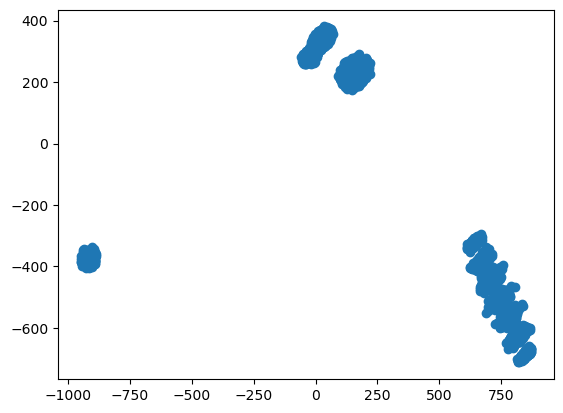

In [8]:
data_path = '../data/fold_orders_csvs/fold_iters_pre_expansion.csv'
with open(data_path, 'r') as file:
    lines = file.readlines()

# imported into a np array; try using pd to keep labels and color the figure
data = []
labels = []
for line in lines:
    if line[0] == ',':
        continue
    fo = line.split(',')[3:-3]
    pre = line.split(',')[-1].strip()  # pre-expansion labels
    data.append(fo)
np.array(data)

pca = PCA(n_components=2)
principalComponents = pca.fit_transform(data)

x, y = list(zip(*principalComponents))  # for each list of len=2, turn first elements into list x, turn second elements into list y
plt.scatter(x, y)
len(x)

Index(['#A6CEE3', '#A6CEE3', '#FDC16E', '#E21C1C', '#E21C1C', '#FB9B98',
       '#CAB2D6', '#E21C1C', '#FB9B98', '#6B3A99',
       ...
       '#CAB2D6', '#31A12C', '#2576B4', '#FDC16E', '#E21C1C', '#2576B4',
       '#A6CEE3', '#6B3A99', '#B1E08A', '#CAB2D6'],
      dtype='object', length=10000)


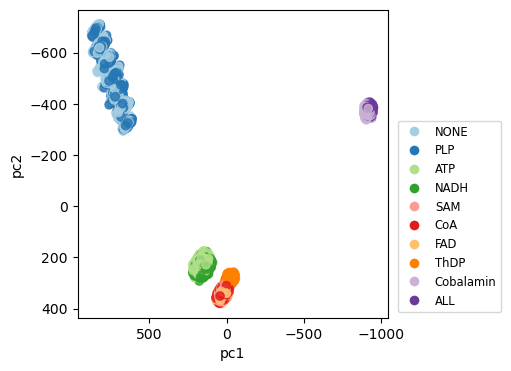

In [9]:
# color by pre label

data_path = '../data/fold_orders_csvs/fold_iters_pre_expansion.csv'
with open(data_path, 'r') as file:
    lines = file.readlines()

data = []  # 10,000 * 397
labels = []  # 10,000
for line in lines:
    if line[0] == ',':
        continue
    fo = line.split(',')[3:-3]
    pre = line.split(',')[-1].strip()  # pre-expansion labels
    data.append(fo)
    labels.append(pre)
np.array(data)
df = pd.DataFrame(data, index=labels)

label_colors = {'NONE': '#A6CEE3', 'C00002': '#B1E08A', 'C00004': '#31A12C', 'C00010': '#E21C1C', 'C00016': '#FDC16E', 'C00019': '#FB9B98', 'Z00009': '#CAB2D6', 'Z00035': '#2576B4', 'Z00047': '#FF8000', 'ALL': '#6B3A99'}
label_colors2 = {'NONE': 'NONE', 'Z00035': 'PLP', 'C00002': 'ATP', 'C00004': 'NADH', 'C00019': 'SAM', 'C00010': 'CoA', 'C00016': 'FAD', 'Z00047': 'ThDP', 'Z00009': 'Cobalamin', 'ALL': 'ALL'}
# Map index values to their corresponding colors
colors_by_label = df.index.map(label_colors)
print(colors_by_label)

pca = PCA(n_components=2)
principal_components = pca.fit_transform(data)

# Create a scatter plot with colored points based on the index labels
plt.figure(figsize=(4, 4))
plt.scatter(principal_components[:, 0], principal_components[:, 1], c=colors_by_label, alpha=0.8)
    
plt.xlabel('pc1')
plt.ylabel('pc2')

plt.gca().invert_yaxis()
plt.gca().invert_xaxis()

# add legend
legend_labels = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=label_colors[label], markersize=8, label=label_colors2[label]) for label in label_colors2.keys()]
# plt.legend(handles=legend_labels, loc="lower center", fontsize='small')
plt.legend(
    handles=legend_labels,
    loc="lower center",
    fontsize='small',
    bbox_to_anchor=(1.2, 0)  # Adjust position outside the plot
)

# plt.savefig('PCA.png', dpi=300, bbox_inches='tight')
plt.show()

## using new data

In [10]:
combined_df = pd.DataFrame()

for pre in ['NONE', 'Z00035', 'preATP', 'C00004', 'C00019', 'C00010', 'C00016', 'Z00047', 'Z00009', 'ALL']:
    data_path = f'../data/1000runs_csvs/folds_folditer_pre-expansion_1000runs/folds_folditer_{pre}.csv'
    
    df = pd.read_csv(data_path, index_col=0).T
    df = df.drop(['fold_independent', 'spontaneous'], errors='ignore', axis=1)
    df.index = [pre] * len(df)  # Set the prefix as the index for this DataFrame
    
    # Combine the DataFrames along rows
    combined_df = pd.concat([combined_df, df], axis=0)
    # randomize rows so that points overlap with each other
    combined_df = combined_df.sample(frac=1, random_state=42)
combined_df.head()

,2002,1,2487,2006,2003,246,304,4126,62,7542,...,4046,4025,4272,3281,3456,3843,3579,4036,4035,4054
C00010,2,7,42,4,3,15,9,130,129,43,...,368,365,366,367,369,369,370,373,373,373
Z00009,3,14,65,5,2,25,15,179,189,66,...,365,364,366,367,368,368,369,373,373,373
Z00047,2,7,48,4,3,19,8,141,139,50,...,364,363,365,366,370,370,371,372,372,372
C00016,2,6,43,4,3,15,9,128,142,44,...,368,365,365,366,371,371,372,373,373,373
Z00035,2,4,15,3,5,12,9,39,42,23,...,362,360,361,363,364,364,365,368,368,368


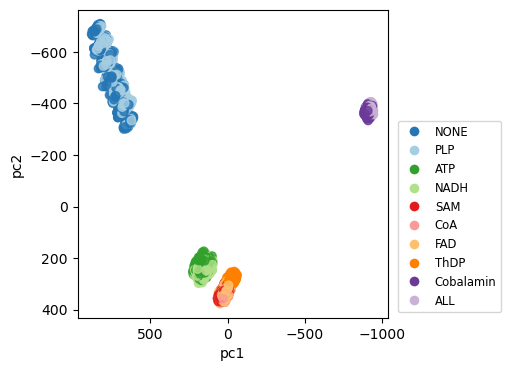

In [11]:
label_colors = {'NONE': '#2576B4', 'Z00035': '#A6CEE3', 'preATP': '#31A12C', 'C00004': '#B1E08A', 'C00010': '#FB9B98', 'C00016': '#FDC16E', 'C00019': '#E21C1C', 'Z00009': '#6B3A99', 'Z00047': '#FF8000', 'ALL': '#CAB2D6'}
label_colors2 = {'NONE': 'NONE', 'Z00035': 'PLP', 'preATP': 'ATP', 'C00004': 'NADH', 'C00019': 'SAM', 'C00010': 'CoA', 'C00016': 'FAD', 'Z00047': 'ThDP', 'Z00009': 'Cobalamin', 'ALL': 'ALL'}
# Map index values to their corresponding colors
colors_by_label = combined_df.index.map(label_colors).tolist()
data = combined_df.values

pca = PCA(n_components=2)
principal_components = pca.fit_transform(data)

# Create a scatter plot with colored points based on the index labels
plt.figure(figsize=(4, 4))
plt.scatter(principal_components[:, 0], principal_components[:, 1], c=colors_by_label, alpha=0.8)
    
plt.xlabel('pc1')
plt.ylabel('pc2')

plt.gca().invert_yaxis()
plt.gca().invert_xaxis()

# add legend
legend_labels = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=label_colors[label], markersize=8, label=label_colors2[label]) for label in label_colors2.keys()]
# plt.legend(handles=legend_labels, loc="lower center", fontsize='small')
plt.legend(
    handles=legend_labels,
    loc="lower center",
    fontsize='small',
    bbox_to_anchor=(1.2, 0)  # Adjust position outside the plot
)

# plt.savefig('PCA.png', dpi=300, bbox_inches='tight')
plt.show()

# Fold orders across different pre-expansions

In [ ]:
# Seed(NONE), ATP, CoA, Full(ALL)

In [90]:
pre2x2foMeanStd = {}

for pre in ['NONE', 'Z00035', 'preATP', 'C00004', 'C00019', 'C00010', 'C00016', 'Z00047', 'Z00009', 'ALL']:

    # make df
    data_path = f'../data/1000runs_csvs/folds_folditer_pre-expansion_1000runs/folds_folditer_{pre}.csv'
    df = pd.read_csv(data_path, index_col=0).T
    df = df.drop(['fold_independent', 'spontaneous'], errors='ignore', axis=1)
    df.index = [pre] * len(df)  # Set the prefix as the index for this DataFrame
    
    x2foMeanStd = {}
    # calculate mean, std fold order for each fold
    for x in df.columns:
        x2foMeanStd[x] = (np.mean(df[x])-1, np.std(df[x]))  # -1 to correct for 'spontaneous'

    pre2x2foMeanStd[pre] = x2foMeanStd

In [91]:
pre2x2foMeanStd.keys()

dict_keys(['NONE', 'Z00035', 'preATP', 'C00004', 'C00019', 'C00010', 'C00016', 'Z00047', 'Z00009', 'ALL'])

In [92]:
from itertools import islice

d_NONE = dict(sorted(pre2x2foMeanStd['NONE'].items(), key=lambda item: item[1][0]))
first_25_NONE = dict(islice(d_NONE.items(), 25))

d_preATP = dict(sorted(pre2x2foMeanStd['preATP'].items(), key=lambda item: item[1][0]))
first_25_preATP = dict(islice(d_preATP.items(), 25))

d_C00010 = dict(sorted(pre2x2foMeanStd['C00010'].items(), key=lambda item: item[1][0]))
first_25_C00010 = dict(islice(d_C00010.items(), 25))

d_ALL = dict(sorted(pre2x2foMeanStd['ALL'].items(), key=lambda item: item[1][0]))
first_25_ALL = dict(islice(d_ALL.items(), 25))

In [94]:
folds45 = set(first_25_NONE.keys()) | set(first_25_preATP.keys()) | set(first_25_C00010.keys()) | set(first_25_ALL.keys())
len(folds45)

45

In [95]:
folds45_2_foMean_NONE = {}
for x in folds45:
    folds45_2_foMean_NONE[x] = pre2x2foMeanStd['NONE'][x][0]

folds45_2_foMean_preATP = {}
for x in folds45:
    folds45_2_foMean_preATP[x] = pre2x2foMeanStd['preATP'][x][0]

folds45_2_foMean_C00010 = {}
for x in folds45:
    folds45_2_foMean_C00010[x] = pre2x2foMeanStd['C00010'][x][0]

folds45_2_foMean_ALL = {}
for x in folds45:
    folds45_2_foMean_ALL[x] = pre2x2foMeanStd['ALL'][x][0]

In [96]:
# order by NONE fold_order
folds45_2_foMean_NONE = dict(sorted(folds45_2_foMean_NONE.items(), key=lambda item: item[1]))
folds45_2_foMean_preATP = {k:folds45_2_foMean_preATP[k] for k in folds45_2_foMean_NONE.keys()}
folds45_2_foMean_C00010 = {k:folds45_2_foMean_C00010[k] for k in folds45_2_foMean_NONE.keys()}
folds45_2_foMean_ALL = {k:folds45_2_foMean_ALL[k] for k in folds45_2_foMean_NONE.keys()}

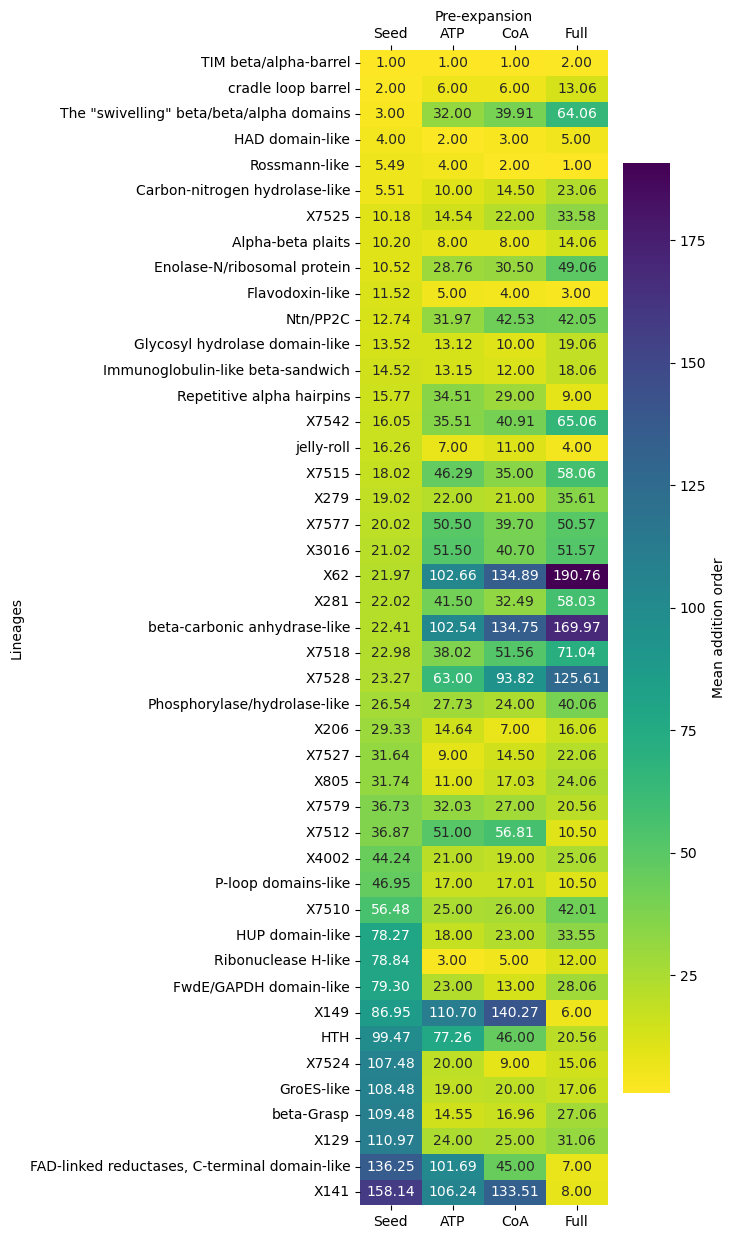

In [98]:
dict1 = folds45_2_foMean_NONE
dict2 = folds45_2_foMean_preATP
dict3 = folds45_2_foMean_C00010
dict4 = folds45_2_foMean_ALL

# Combine the dictionaries into a DataFrame
data = pd.DataFrame({
    'Seed': dict1,
    'ATP': dict2,
    'CoA': dict3,
    'Full': dict4
})  

data.index = [x2name.get(k, f'X{k}') for k in data.index]  # Replace X with name

# Create the heatmap
plt.figure(figsize=(4, 15))
sns.heatmap(data, cmap='viridis_r', annot=True, fmt=".2f", cbar_kws={'label': 'Mean addition order'})

# Customize axis labels
plt.xlabel("Pre-expansion")
plt.ylabel("Lineages")
# Move the x-axis to the top
plt.gca().xaxis.set_label_position('top')
plt.gca().tick_params(axis='x', top=True, labeltop=True)

# plt.savefig('45_fold_orders_pre-exp.svg', dpi=300, bbox_inches='tight')
plt.show()

# Seed set size of each pre-expansion

In [12]:
import os
import pickle

directory = "../data/pre-expansion_seed_cpds/" 

pre_exp2seed_size = {}
for filename in os.listdir(directory):
    file_path = os.path.join(directory, filename)
    
    pre_exp = filename.split('_')[-1].split('.')[0]
    with open(file_path, "rb") as file:
        data = pickle.load(file)
        pre_exp2seed_size[pre_exp] = len(data)
pre_exp2seed_size

{'Z00035': 255,
 'Z00009': 3992,
 'Z00047': 1550,
 'C00019': 1203,
 'C00002': 484,
 'C00016': 1353,
 'C00010': 1291,
 'C00004': 601,
 'ALL': 4291,
 'NONE': 80}


# Loadings of PCA to figure out: folds that change the most


In [14]:
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'])
loadings

,PC1,PC2
0,0.000643,0.000551
1,0.006328,0.001363
2,0.032443,-0.009661
3,0.001018,0.001003
4,-0.002194,0.001180
...,...,...
392,0.002554,-0.002250
393,0.002554,-0.002250
394,0.002883,-0.002769
395,0.002883,-0.002769


In [15]:
loading1 = loadings['PC1']
print(loading1)

0      0.000643
1      0.006328
2      0.032443
3      0.001018
4     -0.002194
         ...   
392    0.002554
393    0.002554
394    0.002883
395    0.002883
396    0.002883
Name: PC1, Length: 397, dtype: float64


# Loading vs. each pre-expansion category

In [16]:
# save as csv

k = list(xgroup2fo.keys())
v = loading1.tolist()

xgroup2loading = dict(zip(k, v))
# dict2csv(xgroup2loading, 'xgroup2loading.csv')

# Are loadings different for different preexpansion?

In [17]:
NONE = data_dict0["NONE"]
C00016 = data_dict0['C00016']
C00010 = data_dict0['C00010']
C00019 = data_dict0['C00019']
Z00009 = data_dict0['Z00009']
ALL = data_dict0['ALL']
C00002 = data_dict0['C00002']
Z00035 = data_dict0['Z00035']
Z00047 = data_dict0['Z00047']
C00004 = data_dict0['C00004']

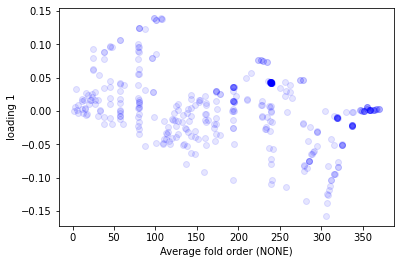

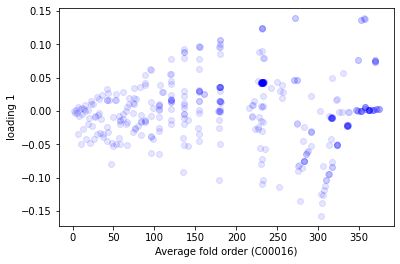

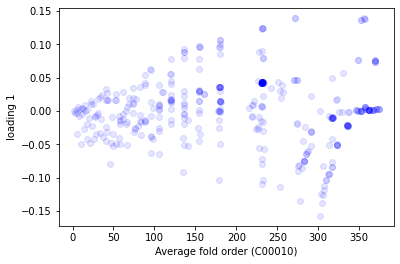

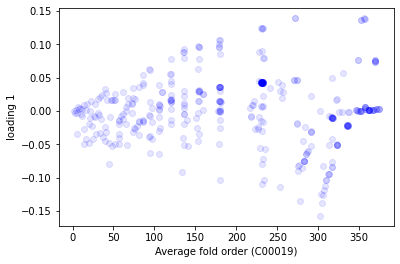

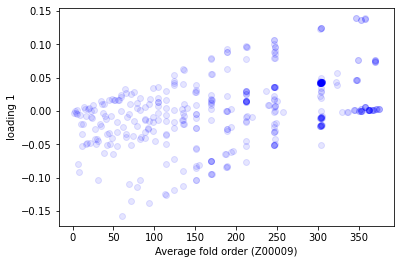

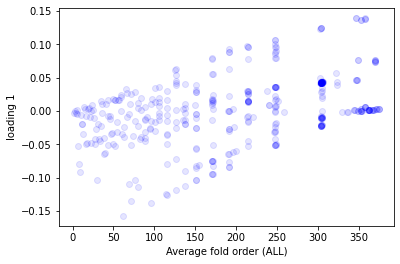

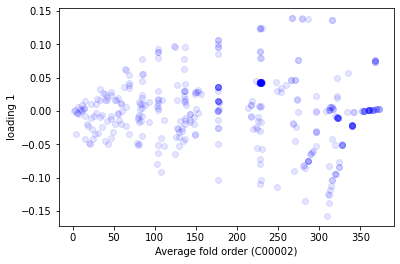

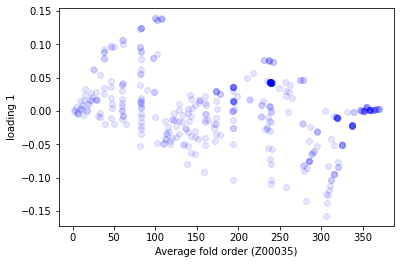

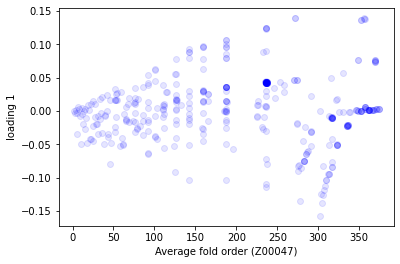

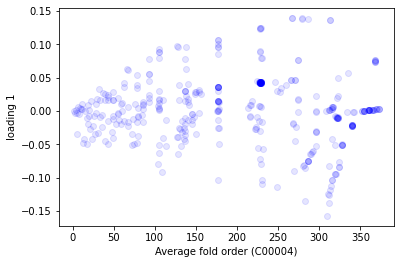

In [18]:
plt.scatter(NONE, loading1, marker='o', color='b', alpha = 0.1, zorder=2)
plt.xlabel('Average fold order (NONE)')
plt.ylabel('loading 1')
plt.show()

plt.scatter(C00016, loading1, marker='o', color='b', alpha = 0.1, zorder=2)
plt.xlabel('Average fold order (C00016)')
plt.ylabel('loading 1')
plt.show()

plt.scatter(C00010, loading1, marker='o', color='b', alpha = 0.1, zorder=2)
plt.xlabel('Average fold order (C00010)')
plt.ylabel('loading 1')
plt.show()

plt.scatter(C00019, loading1, marker='o', color='b', alpha = 0.1, zorder=2)
plt.xlabel('Average fold order (C00019)')
plt.ylabel('loading 1')
plt.show()

plt.scatter(Z00009, loading1, marker='o', color='b', alpha = 0.1, zorder=2)
plt.xlabel('Average fold order (Z00009)')
plt.ylabel('loading 1')
plt.show()

plt.scatter(ALL, loading1, marker='o', color='b', alpha = 0.1, zorder=2)
plt.xlabel('Average fold order (ALL)')
plt.ylabel('loading 1')
plt.show()

plt.scatter(C00002, loading1, marker='o', color='b', alpha = 0.1, zorder=2)
plt.xlabel('Average fold order (C00002)')
plt.ylabel('loading 1')
plt.show()

plt.scatter(Z00035, loading1, marker='o', color='b', alpha = 0.1, zorder=2)
plt.xlabel('Average fold order (Z00035)')
plt.ylabel('loading 1')
plt.show()

plt.scatter(Z00047, loading1, marker='o', color='b', alpha = 0.1, zorder=2)
plt.xlabel('Average fold order (Z00047)')
plt.ylabel('loading 1')
plt.show()

plt.scatter(C00004, loading1, marker='o', color='b', alpha = 0.1, zorder=2)
plt.xlabel('Average fold order (C00004)')
plt.ylabel('loading 1')
plt.show()

# multifold injections as a function of iteration number for the various pre-expansions

In [19]:
df

,0,1,2,3,4,5,6,7,8,9,...,387,388,389,390,391,392,393,394,395,396
NONE,2,3,4,5,6,7,8,9,10,11,...,362,363,364,365,366,366,367,368,368,368
NONE,2,3,4,5,6,7,13,15,16,8,...,362,361,361,364,366,366,367,368,368,368
C00016,2,6,42,4,3,16,23,33,5,9,...,364,365,366,367,371,371,372,373,373,373
C00010,2,7,38,4,3,16,23,32,5,9,...,365,365,366,368,370,370,371,374,374,374
C00010,2,7,44,4,3,16,23,32,5,9,...,364,364,367,366,371,371,372,373,373,373
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Z00035,2,4,15,3,5,12,9,31,6,8,...,361,362,364,363,366,366,367,369,369,369
NONE,2,3,4,5,7,6,9,12,13,14,...,362,361,361,364,366,366,367,368,368,368
ALL,3,14,65,6,2,24,34,50,4,15,...,365,365,367,368,369,369,370,374,374,374
C00002,2,7,33,3,5,11,16,29,6,9,...,364,364,367,366,368,368,369,372,372,372


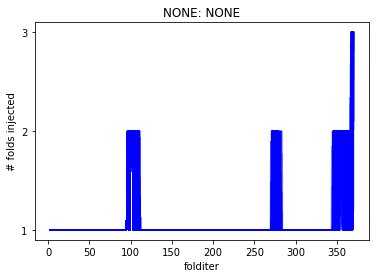

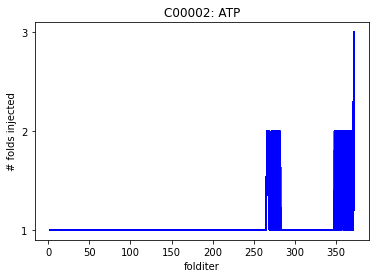

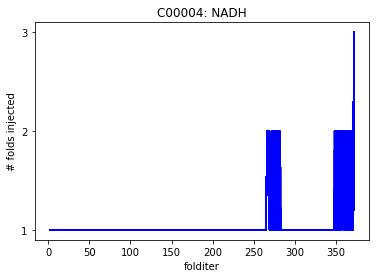

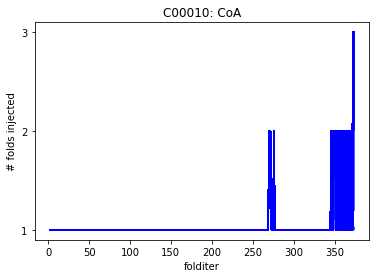

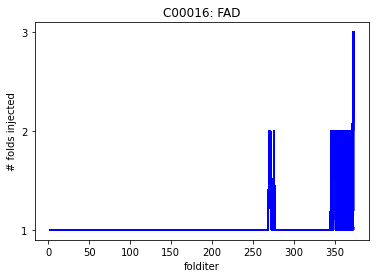

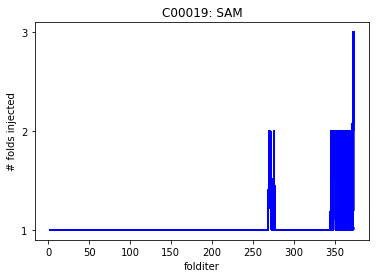

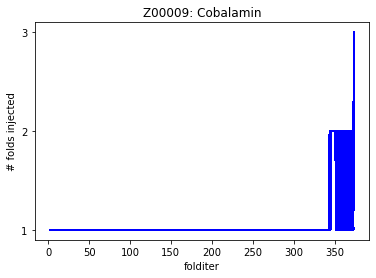

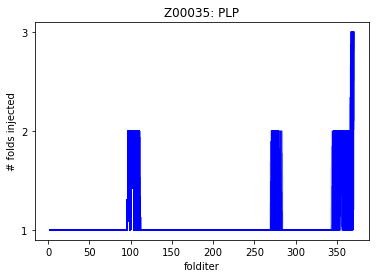

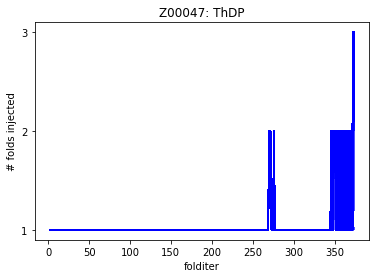

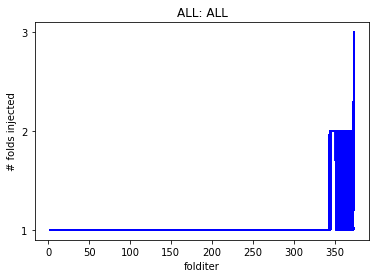

In [20]:
for label in label_colors.keys():
    row = 0
    for index in df.index:
        if index == label:
            iter2foldsNum = {}
            for x, i in dict(df.iloc[row]).items():
                if int(i) not in iter2foldsNum:
                    iter2foldsNum[int(i)] = 1
                else:
                    iter2foldsNum[int(i)] += 1
            od = OrderedDict(sorted(iter2foldsNum.items()))
            plt.plot(od.keys(), od.values(), color='blue', alpha=0.01)
        row += 1

    plt.title(f"{label}: {label_colors2[label]}")
    plt.xlabel("folditer")
    plt.ylabel("# folds injected")
    plt.yticks([1, 2, 3])
    plt.savefig(f"multiple_injection_{label}", dpi=300, bbox_inches = 'tight')
    plt.show()

# plot the fold-compound discovery curve for the “fastest” trajectory for each of the pre-expansion sets

## 1. look for fastest run

In [134]:
cpd2name = csv2dict('../data/assets/cpd2nameShort.csv')
zpd2name = csv2dict('../data/assets/zpd2name.csv')
labels = {'NONE': 'NONE', 'Z00035': 'PLP', 'C00002': 'ATP', 'C00004': 'NADH', 'C00019': 'SAM', 'C00010': 'CoA', 'C00016': 'FAD', 'Z00047': 'ThDP', 'Z00009': 'Cobalamin', 'ALL': 'ALL'}

In [57]:
folder_path = '../cpds_folditer_pre-expansion_1000runs/'
files_pattern = '*.csv'
files = glob.glob(folder_path + files_pattern)

# Iterate over each file
for file_path in files:
        print(file_path)

../cpds_folditer_pre-expansion_1000runs/cpds_folditer_pre-expansion_1000runs_ALL.csv
../cpds_folditer_pre-expansion_1000runs/cpds_folditer_pre-expansion_1000runs_Z00047.csv
../cpds_folditer_pre-expansion_1000runs/cpds_folditer_pre-expansion_1000runs_C00019.csv
../cpds_folditer_pre-expansion_1000runs/cpds_folditer_pre-expansion_1000runs_NONE.csv
../cpds_folditer_pre-expansion_1000runs/cpds_folditer_pre-expansion_1000runs_Z00035.csv
../cpds_folditer_pre-expansion_1000runs/cpds_folditer_pre-expansion_1000runs_Z00009.csv
../cpds_folditer_pre-expansion_1000runs/cpds_folditer_pre-expansion_1000runs_C00016.csv
../cpds_folditer_pre-expansion_1000runs/cpds_folditer_pre-expansion_1000runs_C00002.csv
../cpds_folditer_pre-expansion_1000runs/cpds_folditer_pre-expansion_1000runs_C00004.csv
../cpds_folditer_pre-expansion_1000runs/cpds_folditer_pre-expansion_1000runs_C00010.csv


529 = index of seed with fastest growth: 
55773 = seed with fastest growth: 


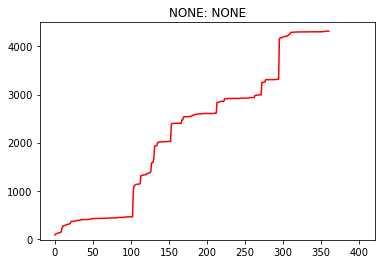

In [525]:
### change file path here:
label = 'NONE'
df_optimal = pd.read_csv(f'../cpds_folditer_pre-expansion_1000runs/cpds_folditer_pre-expansion_1000runs_{label}.csv', index_col=0)


# fo vs. [compounds]

fo2cmpds_list = []
for run in df_optimal.columns[0:1000]:  # 1000 optimal runs
    fo2cmpds = {}
    for c, order in df_optimal[run].iteritems():
        if order not in fo2cmpds.keys():
            fo2cmpds[order] = [c]
        else:
            fo2cmpds[order].append(c)
    fo2cmpds_list.append(fo2cmpds)

# fo vs. # compounds (cummulative)
    
fo2cmpdNum_list = []
for run in fo2cmpds_list:                   
    fo2cmpdNum = {}
    cumm = 0
    for i in range(0, max(run.keys())): 
        if i in run.keys():
            cumm += len(run[i])
        fo2cmpdNum[i] = cumm
    fo2cmpdNum_list.append(fo2cmpdNum)
    
max_area = [0, 0]
index = 0
for run in fo2cmpdNum_list:
    area = sum(run.values())
    if area > max_area[1]:
        max_area = [index, area]
    index += 1
print(f"{max_area[0]} = index of seed with fastest growth: ")
print(f"{df_optimal.columns[max_area[0]]} = seed with fastest growth: ")
fastest_index =max_area[0]

# get seed of fastest run
df_optimal.columns[fastest_index]

maxDict = fo2cmpdNum_list[fastest_index]
sum(maxDict.values())

plt.plot(maxDict.keys(), maxDict.values(), color='red', alpha = 1,zorder=2)
plt.xlim([-20, 420])
plt.ylim([-20, 4500])
plt.title(f"{label}: {labels[label]}")
# plt.savefig(f'fold_order_vs_cumm_cmpds_bestRun_{label}.svg', dpi=300, bbox_inches = 'tight', transparent=True)
plt.show()

## 2. draw fastest run

In [358]:
# get seeds of fastest runs, grab pkl files => grab folditers (multiple)

# fastest = pd.read_pickle('../fastest_seeds_pre-expansion/2023-09-30_07-16-50_rules_to_rn_randomSeed_38968_preExpansion_ALL.pkl.gz')
# fastest = pd.read_pickle('../fastest_seeds_pre-expansion/2023-09-30_03-20-20_rules_to_rn_randomSeed_23551_preExpansion_Z00047_iter35.pkl.gz')
# fastest = pd.read_pickle('../fastest_seeds_pre-expansion/2023-09-30_03-34-05_rules_to_rn_randomSeed_28462_preExpansion_C00019_iter30.pkl.gz')
# fastest = pd.read_pickle('../fastest_seeds_pre-expansion/2023-09-29_20-41-57_rules_to_rn_randomSeed_55773_preExpansion_NONE.pkl.gz')
# fastest = pd.read_pickle('../fastest_seeds_pre-expansion/2023-09-30_05-38-41_rules_to_rn_randomSeed_14086_preExpansion_Z00035_iter8.pkl.gz')
# fastest = pd.read_pickle('../fastest_seeds_pre-expansion/2023-09-30_00-27-09_rules_to_rn_randomSeed_6523_preExpansion_Z00009_iter55.pkl.gz')
# fastest = pd.read_pickle('../fastest_seeds_pre-expansion/2023-09-29_20-57-02_rules_to_rn_randomSeed_40671_preExpansion_C00016_iter33.pkl.gz')
# fastest = pd.read_pickle('../fastest_seeds_pre-expansion/2023-09-29_18-15-49_rules_to_rn_randomSeed_1028_preExpansion_C00002_iter20.pkl.gz')
# fastest = pd.read_pickle('../fastest_seeds_pre-expansion/2023-09-29_18-42-26_rules_to_rn_randomSeed_46685_preExpansion_C00004_iter22.pkl.gz')
fastest = pd.read_pickle('../fastest_seeds_pre-expansion/2023-09-30_00-42-26_rules_to_rn_randomSeed_59251_preExpansion_C00010_iter32.pkl.gz')


iter2folds = {}
for fold, i in fastest.folds_folditer.items():
    if i not in iter2folds:
        iter2folds[i] = [fold]
    else:
        iter2folds[i].append(fold)
multiple = [i for i, fold in iter2folds.items() if len(fold) != 1]

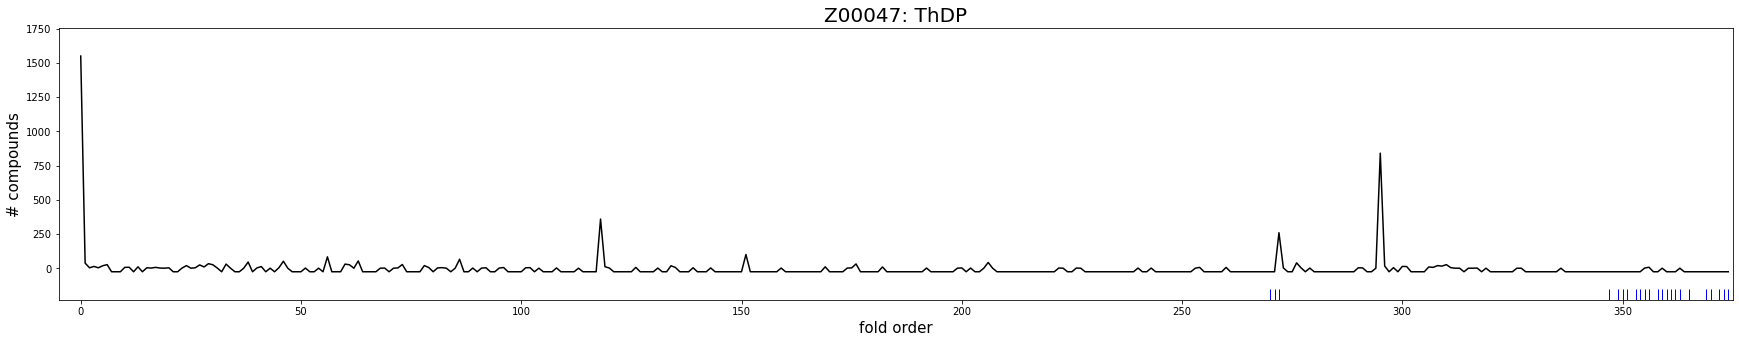

In [490]:
# fo vs. # compounds (NOT cummulative)
    
fo2cmpdNum_fastest = {}
for fo, cpds in fo2cmpds_list[fastest_index].items():                   
    fo2cmpdNum_fastest[fo] = len(cpds)
    
fo2cmpdNum_fastest_full = {}
for i in range(0, max(fo2cmpdNum_fastest.keys())):
    if i not in fo2cmpdNum_fastest.keys():
        fo2cmpdNum_fastest_full[i] = -25
    else:
        fo2cmpdNum_fastest_full[i] = fo2cmpdNum_fastest[i]
        
plt.figure(figsize=(30, 5))

# extend right end
x = list(fo2cmpdNum_fastest_full.values())
for i in range(len(iter2folds) - len(fo2cmpdNum_fastest_full)):
    x.append(-25)
plt.plot(x, color='k')

# add rugplot
sns.rugplot(multiple, height=0.04, color='blue')  # double fold injection

plt.xlim([-5, len(iter2folds)])
plt.title(f'{label}: {labels[label]}', fontsize=20)
plt.ylabel('# compounds', fontsize=15)
plt.xlabel('fold order', fontsize=15)
# plt.savefig(f'foldorder_vs_cpd_fastest_{label}.svg', dpi=300, bbox_inches='tight')
plt.show()

In [416]:
# timing of Oxygen discovery
print(label, labels[label])
print(np.mean(df_optimal.loc['C00007']), np.std(df_optimal.loc['C00007']))

C00004 NADH
308.293 5.839790321578333


In [491]:
# time until first peak > 50

print(label, labels[label])
for i, num in fo2cmpdNum_fastest_full.items():
    if num > 50 and i != 0:
        print(f"folditer={i}, #cpds={num}")
        break
for i, num in fo2cmpdNum_fastest_full.items():
    if num > 50 and i != 0 and i != 1:
        print(f"folditer={i}, #cpds={num}")
        break

Z00047 ThDP
folditer=46, #cpds=52
folditer=46, #cpds=52


In [360]:
# how many folds add ZERO compounds?

count = 0
for fo, num in fo2cmpdNum_fastest_full.items():
    if num == -25:
        count += 1
count

233

## annotate compounds

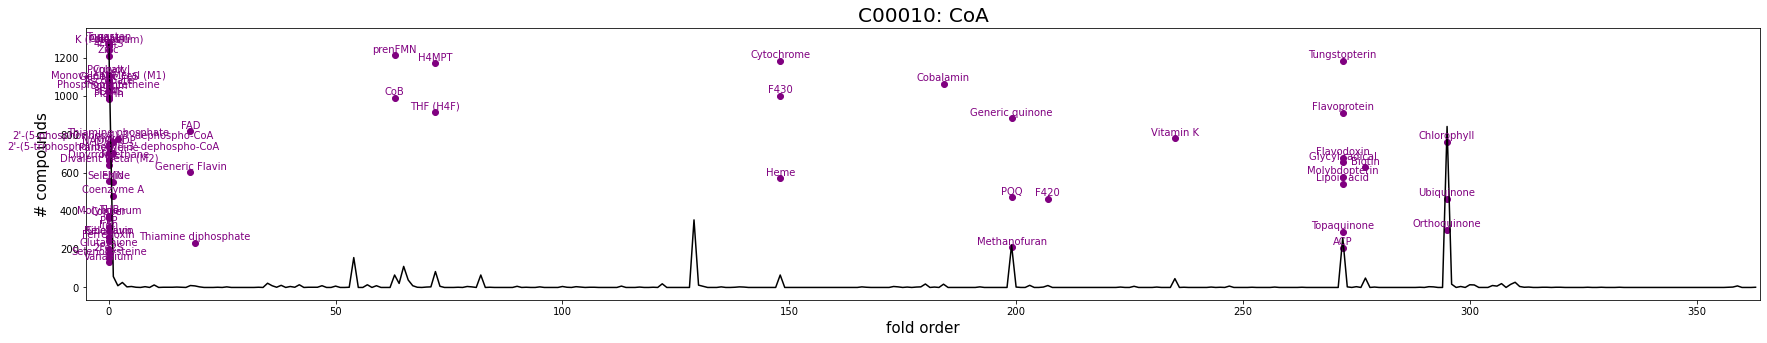

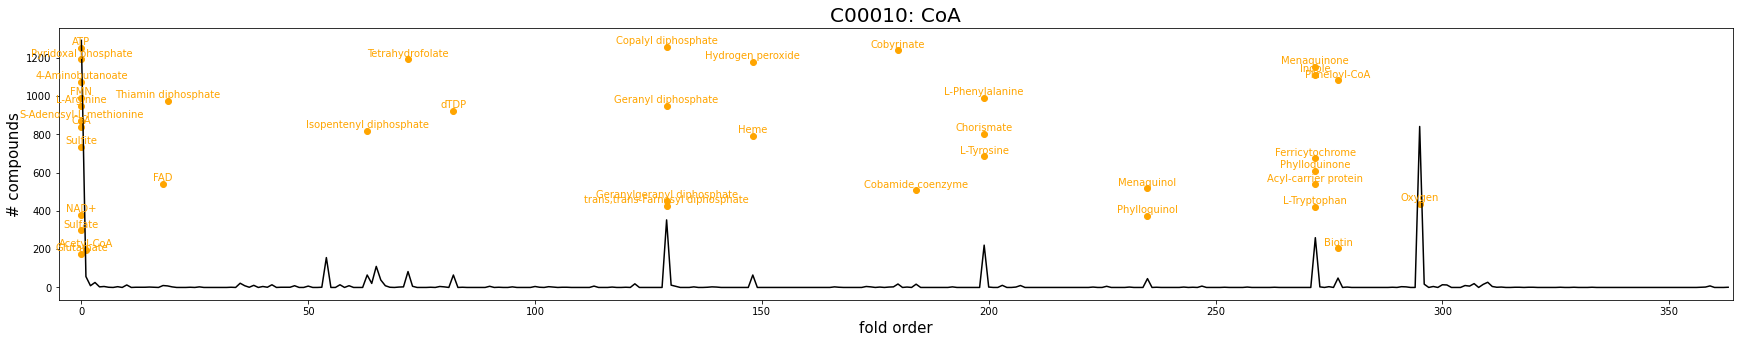

In [361]:
cpd2iterZ = {}
for folditer in fo2cmpds_list[fastest_index].keys():
    for c in fo2cmpds_list[fastest_index][folditer]:
        if c.startswith('Z'):
            cpd2iterZ[c] = folditer

cpd2iter = {}
for cpd in ['C00448', 'C11901', 'C00341', 'C00353', 'C00923', 'C00463', 'C00229', 'C05819', 'C03313', 'C00027', 'C00032', 'C00059', 'C00094', 'C05773', 'C00251', 'C00082', 'C00079', 'C00078', 'C02059', 'C00828', 'C01063', 'C00120', 'C00018', 'C00302', 'C00334', 'C11440', 'C00002', 'C00003', 'C00010', 'C00024', 'C00129', 'C00068', 'C00019', 'C00101', 'C00016', 'C00061', 'C00363', 'C00194', 'C00062', 'C00007']:
    for folditer in fo2cmpds_list[fastest_index].keys():
        for c in fo2cmpds_list[fastest_index][folditer]:
            if c == cpd:
                cpd2iter[c] = folditer

                
# re-scale to remove -25 dip
fo2cmpdNum_fastest_full = {}
for i in range(0, max(fo2cmpdNum_fastest.keys())):
    if i not in fo2cmpdNum_fastest.keys():
        fo2cmpdNum_fastest_full[i] = 0
    else:
        fo2cmpdNum_fastest_full[i] = fo2cmpdNum_fastest[i]

# zpd
    
plt.figure(figsize=(30, 5))
plt.plot(fo2cmpdNum_fastest_full.values(), color='k')

# x = list(fo2cmpdNum_fastest_full.values())
# for i in range(len(iter2folds) - len(fo2cmpdNum_fastest_full)):
#     x.append(-25)
# plt.plot(x, color='k')

for key, value in cpd2iterZ.items():
    position = random.randint(100, max(fo2cmpdNum_fastest_full.values()))
    plt.text(value, position, zpd2name[key], ha='center', va='bottom', color='purple')
    plt.scatter(value, position-5, color='purple')

plt.xlim([-5, len(fo2cmpdNum_fastest_full)])
plt.title(f'{label}: {labels[label]}', fontsize=20)
plt.ylabel('# compounds', fontsize=15)
plt.xlabel('fold order', fontsize=15)
plt.savefig(f'foldorder_vs_cpd_fastest_{label}_zpd.svg', dpi=300, bbox_inches='tight')
plt.show()


# cpd

plt.figure(figsize=(30, 5))
plt.plot(fo2cmpdNum_fastest_full.values(), color='k')

# x = list(fo2cmpdNum_fastest_full.values())
# for i in range(len(iter2folds) - len(fo2cmpdNum_fastest_full)):
#     x.append(-25)
# plt.plot(x, color='k')

for key, value in cpd2iter.items():
    position = random.randint(100, max(fo2cmpdNum_fastest_full.values()))
    plt.text(value, position, cpd2name[key], ha='center', va='bottom', color='orange')
    plt.scatter(value, position-5, color='orange')

plt.xlim([-5, len(fo2cmpdNum_fastest_full)])
plt.title(f'{label}: {labels[label]}', fontsize=20)
plt.ylabel('# compounds', fontsize=15)
plt.xlabel('fold order', fontsize=15)
plt.savefig(f'foldorder_vs_cpd_fastest_{label}_cpd.svg', dpi=300, bbox_inches='tight')
plt.show()

## histogram for oxygen discovery timing

In [436]:
oxy_timings = {}
for label in labels.keys():
    if label != 'ALL' and label != 'Z00009':  # remove ALL and cobalamin
        df = pd.read_csv(f'../cpds_folditer_pre-expansion_1000runs/cpds_folditer_pre-expansion_1000runs_{label}.csv', index_col=0)
        timing = df.loc['C00007']
        oxy_timings[label] = timing

In [447]:
for key in oxy_timings.keys():
    print(key, labels[key])

NONE NONE
Z00035 PLP
C00002 ATP
C00004 NADH
C00019 SAM
C00010 CoA
C00016 FAD
Z00047 ThDP


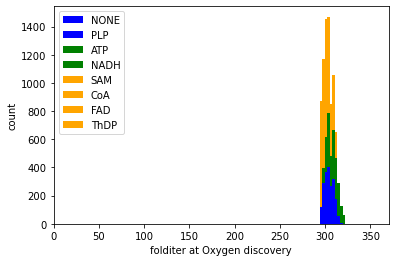

In [461]:
data = [list(oxy_timings[label]) for label in oxy_timings.keys()]

colors = ['blue', 'blue', 'green', 'green', 'orange', 'orange', 'orange', 'orange']
plt.hist(data, stacked=True, bins=10, color=colors, label=[labels[label] for label in list(oxy_timings.keys())])
plt.xlabel('folditer at Oxygen discovery')
plt.xlim([0, 370])
plt.ylabel('count')
plt.legend(loc='upper left')
plt.savefig('oxygen_discovery_timing_stacked_histogram.svg', dpi=300, bbox_inches = 'tight')
plt.show()

# folditer vs. cumm. #cpd

529 = index of seed with fastest growth
55773 = seed with fastest growth
85 = index of seed with fastest growth
14086 = seed with fastest growth
993 = index of seed with fastest growth
1028 = seed with fastest growth
130 = index of seed with fastest growth
46685 = seed with fastest growth
766 = index of seed with fastest growth
28462 = seed with fastest growth
519 = index of seed with fastest growth
59251 = seed with fastest growth
1 = index of seed with fastest growth
40671 = seed with fastest growth
503 = index of seed with fastest growth
23551 = seed with fastest growth
429 = index of seed with fastest growth
6523 = seed with fastest growth
0 = index of seed with fastest growth
38968 = seed with fastest growth


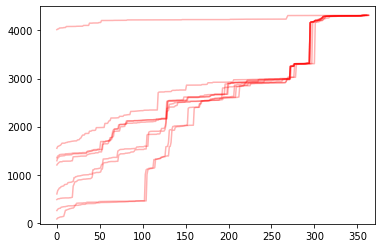

In [546]:
### fastest run from each pre-expansion
for label in labels.keys():
    df_optimal = pd.read_csv(f'../cpds_folditer_pre-expansion_1000runs/cpds_folditer_pre-expansion_1000runs_{label}.csv', index_col=0)


    # fo vs. [compounds]

    fo2cmpds_list = []
    for run in df_optimal.columns[0:1000]:  # 1000 optimal runs
        fo2cmpds = {}
        for c, order in df_optimal[run].iteritems():
            if order not in fo2cmpds.keys():
                fo2cmpds[order] = [c]
            else:
                fo2cmpds[order].append(c)
        fo2cmpds_list.append(fo2cmpds)

    # fo vs. # compounds (cummulative)

    fo2cmpdNum_list = []
    for run in fo2cmpds_list:                   
        fo2cmpdNum = {}
        cumm = 0
        for i in range(0, max(run.keys())): 
            if i in run.keys():
                cumm += len(run[i])
            fo2cmpdNum[i] = cumm
        fo2cmpdNum_list.append(fo2cmpdNum)

    max_area = [0, 0]
    index = 0
    for run in fo2cmpdNum_list:
        area = sum(run.values())
        if area > max_area[1]:
            max_area = [index, area]
        index += 1
    print(f"{max_area[0]} = index of seed with fastest growth")
    print(f"{df_optimal.columns[max_area[0]]} = seed with fastest growth")
    fastest_index =max_area[0]

    # get seed of fastest run
    df_optimal.columns[fastest_index]

    maxDict = fo2cmpdNum_list[fastest_index]
    sum(maxDict.values())

    plt.plot(maxDict.keys(), maxDict.values(), color='red', alpha = 0.3,zorder=2)
plt.xlim([-20, 370])
plt.ylim([-20, 4500])
# plt.savefig(f'fold_order_vs_cumm_cmpds_bestRun_all_pre-exp.svg', dpi=300, bbox_inches = 'tight', transparent=True)
plt.show()

In [575]:
### 1000 runs from each pre-expansion
slopes = {label:[] for label in labels}

for label in labels.keys():
    df_optimal = pd.read_csv(f'../cpds_folditer_pre-expansion_1000runs/cpds_folditer_pre-expansion_1000runs_{label}.csv', index_col=0)

    # fo vs. [compounds]

    fo2cmpds_list = []
    for run in df_optimal.columns[0:1000]:  # 1000 optimal runs
        fo2cmpds = {}
        for c, order in df_optimal[run].iteritems():
            if order not in fo2cmpds.keys():
                fo2cmpds[order] = [c]
            else:
                fo2cmpds[order].append(c)
        fo2cmpds_list.append(fo2cmpds)

    # fo vs. # compounds (cummulative)

    fo2cmpdNum_list = []
    for run in fo2cmpds_list:                   
        fo2cmpdNum = {}
        cumm = 0
        for i in range(0, max(run.keys())): 
            if i in run.keys():
                cumm += len(run[i])
            fo2cmpdNum[i] = cumm
        fo2cmpdNum_list.append(fo2cmpdNum)

    for d in fo2cmpdNum_list:
#         plt.plot(d.keys(), d.values(), color='red', alpha = 0.01, zorder=2)
        slopes[label].append(d[100] - d[0])  # collect slopes between [0, 100]
        # this will terminate with error at ALL

plt.xlim([-20, 370])
plt.ylim([-20, 4500])
# plt.savefig(f'fold_order_vs_cumm_cmpds_1000runs_all_pre-exp.svg', dpi=300, bbox_inches = 'tight', transparent=True)
# plt.show()

KeyError: 100

## slope distributions

In [576]:
slopes.pop('ALL')

[]

In [578]:
slopesAve = {labels[label]:[np.mean(data), np.std(data)] for label, data in slopes.items()}

In [579]:
slopesAve

{'NONE': [377.509, 0.4999189934379369],
 'PLP': [201.0, 0.0],
 'ATP': [1060.872, 68.67307781074037],
 'NADH': [993.906, 50.440610265935526],
 'SAM': [890.0, 0.0],
 'CoA': [841.0, 0.0],
 'FAD': [780.0, 0.0],
 'ThDP': [784.723, 2.1707765891496065],
 'Cobalamin': [203.0, 0.0]}

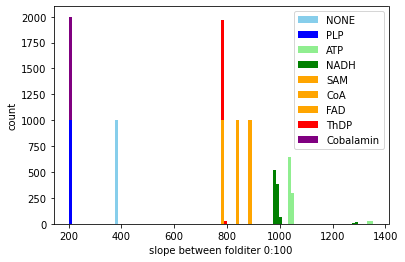

In [581]:
data = [list(slopes[label]) for label in slopes.keys()]

colors = ['skyblue', 'blue', '#90EE90', 'green', 'orange', 'orange', 'orange', 'red', 'purple']
plt.hist(data, stacked=True, bins=100, color=colors, label=[labels[label] for label in list(slopes.keys())])
plt.xlabel('slope between folditer 0:100')
plt.ylabel('count')
plt.legend(loc='upper right')
# plt.savefig('oxygen_discovery_timing_stacked_histogram.svg', dpi=300, bbox_inches = 'tight')
plt.show()

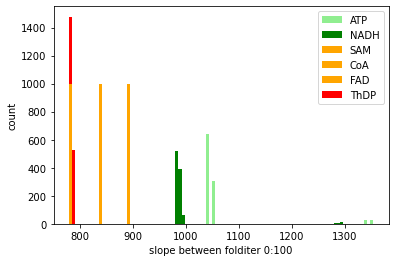

In [573]:
data = [list(slopes[label]) for label in slopes.keys()]

colors = ['#90EE90', 'green', 'orange', 'orange', 'orange', 'red']
plt.hist(data, stacked=True, bins=100, color=colors, label=[labels[label] for label in list(slopes.keys())])
plt.xlabel('slope between folditer 0:100')
plt.ylabel('count')
plt.legend(loc='upper right')
# plt.savefig('oxygen_discovery_timing_stacked_histogram.svg', dpi=300, bbox_inches = 'tight')
plt.show()